In [2]:
!pip install underthesea

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/7.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/7.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/7.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/7.3 MB ? eta -:--:--
   - -------------------------------------- 0.3/7.3 MB ? eta -:--:--
   ---- ----------------------------------- 0.8/7.3 MB 1.8 MB/s eta 0:00:04
   ---------- ----------------------------- 1.8/7.3 MB 2.7 MB/s eta 0:00:02
   -------------------- ------------------- 3.7/7.3 MB 4.3 MB/s eta 0:00:01
   ------------------------------------ --- 6.6/7.3 MB 6.2 MB/s eta 0:00:01
   ---------------------------------------- 7.3/7.3 MB 6.6 MB/s  0:00:01
   ---------------------------------------- 0.0/1.2 MB ? eta -:--:--
   ---------------------------------------- 1.2/1.2 MB 12.1 MB/s  0:00:00

   -------------------- ------------------- 1/2 [underth


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import ast
from wordcloud import WordCloud
from underthesea import word_tokenize

sns.set_theme(style="whitegrid", font_scale=1)

# Professional color palette
normal_color = "#bbd4fc"      # green
misleading_color = "#fc5d6b"  # red
palette = [normal_color, misleading_color]

C:\Users\Vivobook\AppData\Roaming\Python\Python313\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [8]:
gsheet_url = 'https://docs.google.com/spreadsheets/d/e/2PACX-1vTy-E1TWgCnwcmHDShDD57oTe1AdSLldK01hjNMC1N8LviFZqyw0z_e2v3aID5mTUV8sE6pqUvmuqVc/pub?output=csv'

df = pd.read_csv("C:/Users/Vivobook/Documents/mm_detect/data/raw/ads_vietnam_clean.csv")
display(df.head())

,id,page_id,page_name,ad_ creation_time,ad_delivery_start_time,ad_delivery_stop_time,ad_creative_bodies,ad_creative_link_titles,currency,impressions,spend,target_gender,target_ages,target_locations,languages,publisher_platforms,ad_snapshot_url,misinformation
0,823238210316661,102854402460581,FiberOne Boats,2025-11-10,2025-11-10,2025-11-25,['💓💓Bán lỗ mẫu dép nữ tăng cao 6 cm cho mọi l...,['.'],NaN,NaN,NaN,Women,"['18', '65']","[{'name': 'Luân Đôn, Vương quốc Anh', 'num_obf...",['vi'],['facebook'],https://www.facebook.com/ads/archive/render_ad...,1
1,871132209123989,136028396253725,DramaBox-movies and drama 8,2026-02-08,2026-02-08,NaN,['Sau năm năm bị kẹt trong hôn nhân không tình...,['(Lồng tiếng)Cuộc đời hoàn hảo không cần anh'],NaN,NaN,NaN,All,"['18', '65']","[{'name': 'Worldwide', 'num_obfuscated': 0, 't...",['vi'],"['facebook', 'instagram', 'audience_network']",https://www.facebook.com/ads/archive/render_ad...,0
2,877151195021133,828292550372769,DramaBox-drama pendek,2026-02-06,2026-02-08,NaN,['Sau năm năm bị kẹt trong hôn nhân không tình...,['(Lồng tiếng)Cuộc đời hoàn hảo không cần anh'],NaN,NaN,NaN,All,"['18', '65']","[{'name': 'Worldwide', 'num_obfuscated': 0, 't...",['vi'],"['facebook', 'instagram', 'audience_network']",https://www.facebook.com/ads/archive/render_ad...,0
3,881581114655479,136028396253725,DramaBox-movies and drama 8,2026-02-08,2026-02-08,NaN,['Sau năm năm bị kẹt trong hôn nhân không tình...,['(Lồng tiếng)Cuộc đời hoàn hảo không cần anh'],NaN,NaN,NaN,All,"['18', '65']","[{'name': 'Worldwide', 'num_obfuscated': 0, 't...",['vi'],"['facebook', 'instagram', 'audience_network']",https://www.facebook.com/ads/archive/render_ad...,0
4,1227833952148512,580340045172078,Dramawave-New short dramas,2026-02-08,2026-02-08,2026-02-08,"['Tái sinh, Nam Mạt trở nên lạnh lùng và quyết...",['Đích Nữ Tàn Nhẫn Đăng Cơ'],NaN,NaN,NaN,All,"['21', '65']","[{'name': 'Worldwide', 'num_obfuscated': 0, 't...",['vi'],"['facebook', 'instagram', 'audience_network', ...",https://www.facebook.com/ads/archive/render_ad...,0


In [9]:
df.shape

(16678, 18)

In [5]:
df['languages'].value_counts()

,count
languages,
['vi'],10263
['en'],5014
['fr'],98
['it'],58
['es'],42
...,...
"['en', 'it', 'es', 'de', 'fr']",1
"['fr', 'it', 'en', 'es', 'de']",1
"['en', 'it', 'es', 'fr', 'de']",1


In [6]:
df['missinformation'].value_counts()

,count
missinformation,
1,12559
0,4119


/tmp/ipykernel_463/1997389203.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df,
/tmp/ipykernel_463/1997389203.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Normal', 'Misleading'])


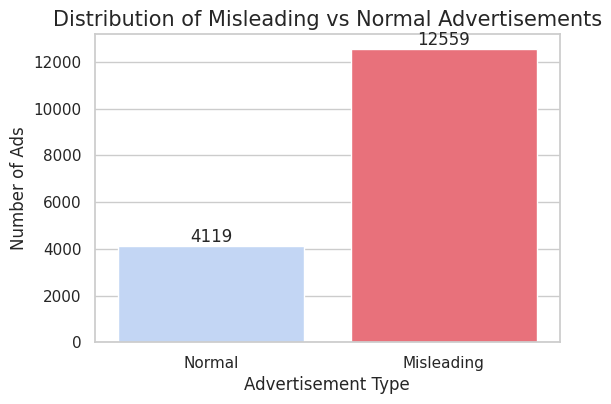

In [7]:
plt.figure(figsize=(6,4))

ax = sns.countplot(data=df,
                   x='missinformation',
                   palette=['#bbd4fc', '#fc5d6b'])

plt.title("Distribution of Misleading vs Normal Advertisements", fontsize=15)
plt.xlabel("Advertisement Type", fontsize=12)
plt.ylabel("Number of Ads", fontsize=12)

ax.set_xticklabels(['Normal', 'Misleading'])

# show numbers on bars
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center', va='bottom')

plt.show()

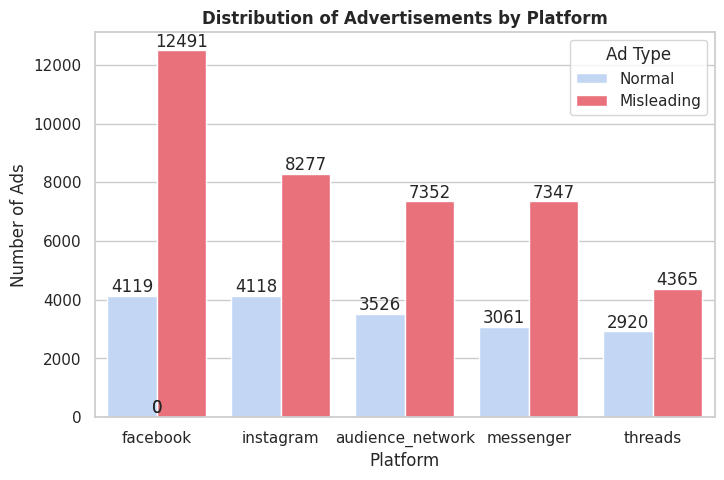

In [8]:
df['publisher_platforms'] = df['publisher_platforms'].apply(ast.literal_eval)
platform_df = df.explode('publisher_platforms')

plt.figure(figsize=(8,5))

ax = sns.countplot(data=platform_df,
                   x='publisher_platforms',
                   hue='missinformation',
                   palette=palette)

plt.title("Distribution of Advertisements by Platform", weight='bold')
plt.xlabel("Platform")
plt.ylabel("Number of Ads")

plt.legend(title="Ad Type", labels=['Normal','Misleading'])

for p in ax.patches:
    ax.annotate(int(p.get_height()),
                (p.get_x()+p.get_width()/2, p.get_height()),
                ha='center', va='bottom')

plt.show()

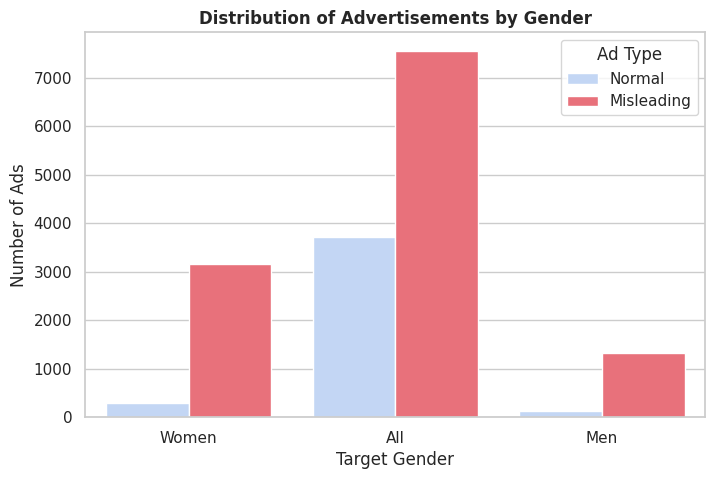

In [9]:
plt.figure(figsize=(8,5))

ax = sns.countplot(data=df,
                   x='target_gender',
                   hue='missinformation',
                   palette=palette)

plt.title("Distribution of Advertisements by Gender", weight='bold')
plt.xlabel("Target Gender")
plt.ylabel("Number of Ads")

plt.legend(title="Ad Type", labels=['Normal','Misleading'])

plt.show()

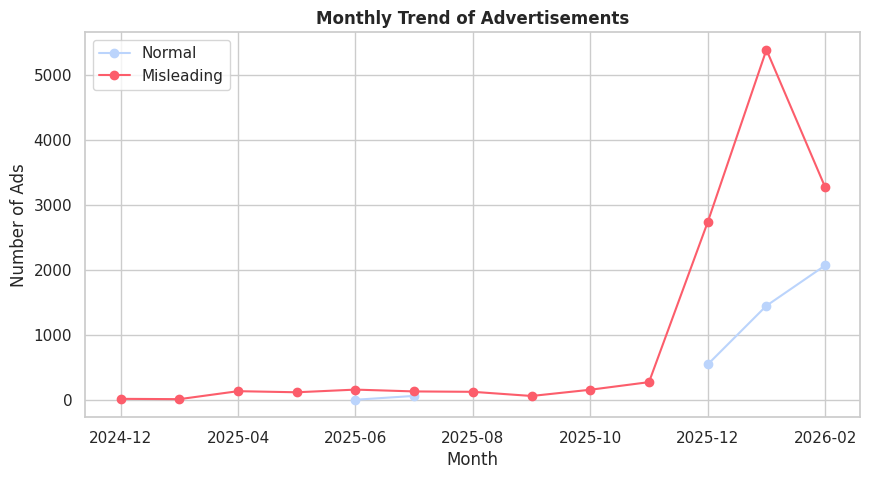

In [10]:
df['ad_creation_time'] = pd.to_datetime(df['ad_creation_time'])

monthly = df.groupby([df['ad_creation_time'].dt.to_period('M'),
                      'missinformation']).size().unstack()

monthly.index = monthly.index.astype(str)

monthly.plot(figsize=(10,5),
             color=palette,
             marker='o')

plt.title("Monthly Trend of Advertisements", weight='bold')
plt.xlabel("Month")
plt.ylabel("Number of Ads")

plt.legend(['Normal','Misleading'])

plt.show()

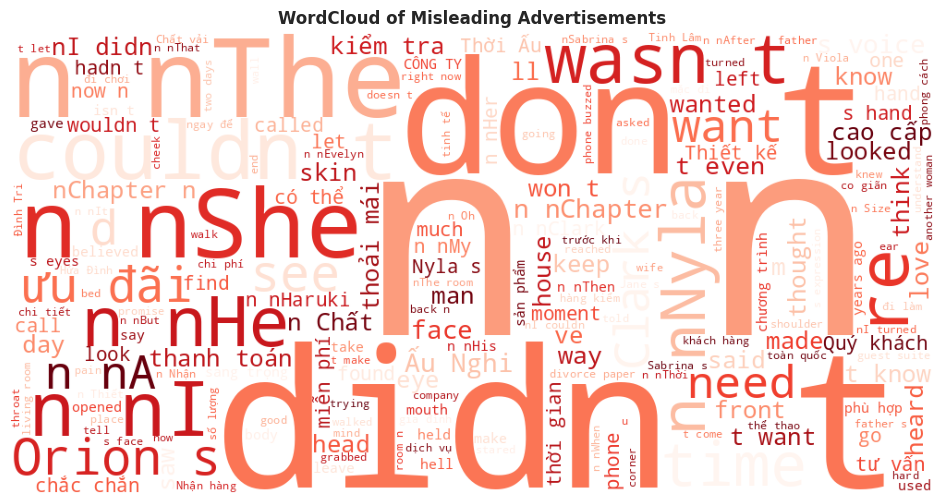

In [11]:
mis_text = df[df['missinformation']==1]['ad_creative_bodies'].astype(str)

text = " ".join(mis_text)

wordcloud = WordCloud(width=1000,
                      height=500,
                      background_color='white',
                      colormap='Reds').generate(text)

plt.figure(figsize=(12,6))

plt.imshow(wordcloud)
plt.axis('off')

plt.title("WordCloud of Misleading Advertisements", weight='bold')

plt.show()

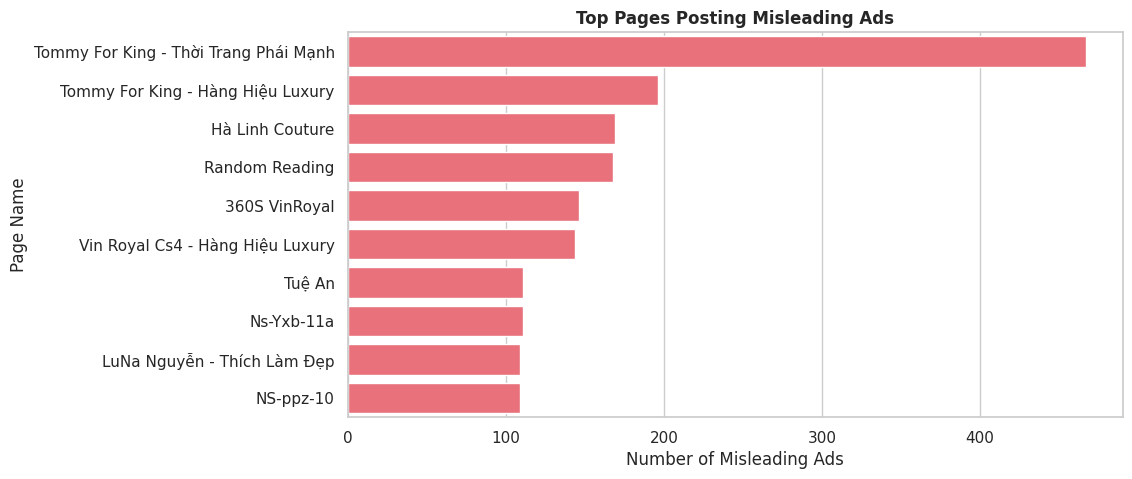

In [12]:
top_pages = df[df['missinformation']==1]['page_name'].value_counts().head(10)

plt.figure(figsize=(10,5))

ax = sns.barplot(x=top_pages.values,
                 y=top_pages.index,
                 color=misleading_color)

plt.title("Top Pages Posting Misleading Ads", weight='bold')
plt.xlabel("Number of Misleading Ads")
plt.ylabel("Page Name")

plt.show()

/tmp/ipykernel_463/431137340.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df,


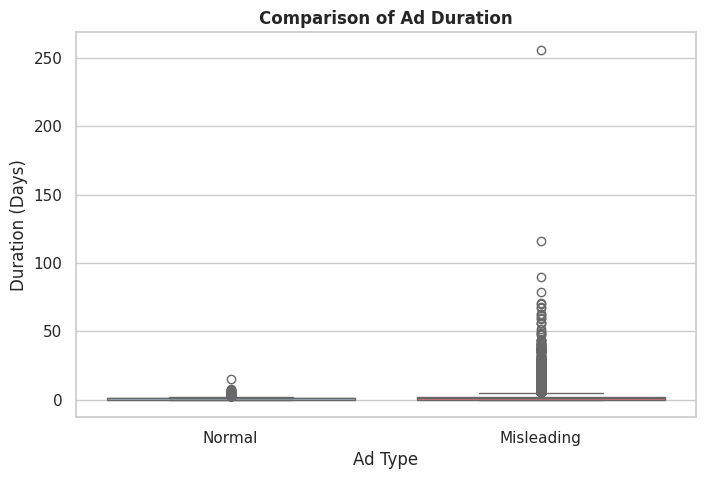

In [13]:
df['ad_delivery_start_time'] = pd.to_datetime(df['ad_delivery_start_time'])
df['ad_delivery_stop_time'] = pd.to_datetime(df['ad_delivery_stop_time'])

df['duration'] = (df['ad_delivery_stop_time']
                  - df['ad_delivery_start_time']).dt.days

plt.figure(figsize=(8,5))

sns.boxplot(data=df,
            x='missinformation',
            y='duration',
            palette=palette)

plt.title("Comparison of Ad Duration", weight='bold')
plt.xlabel("Ad Type")
plt.ylabel("Duration (Days)")

plt.xticks([0,1], ['Normal','Misleading'])

plt.show()

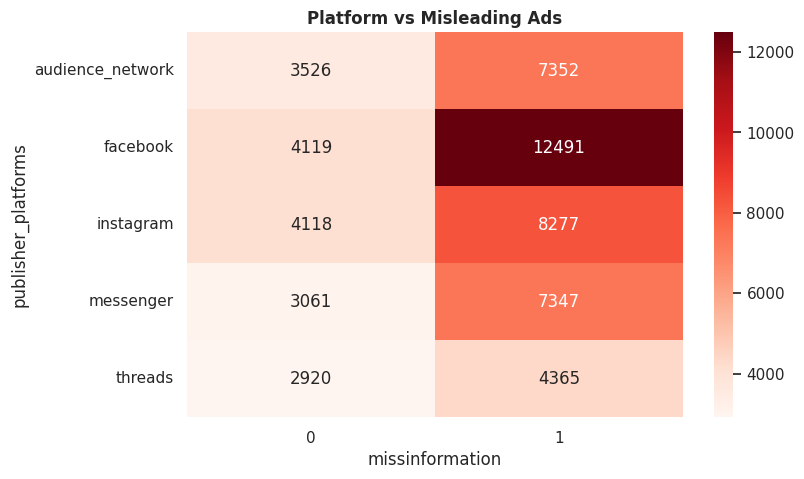

In [14]:
cross = pd.crosstab(platform_df['publisher_platforms'],
                    platform_df['missinformation'])

plt.figure(figsize=(8,5))

sns.heatmap(cross,
            annot=True,
            fmt='d',
            cmap='Reds')

plt.title("Platform vs Misleading Ads", weight='bold')

plt.show()

In [15]:
df['has_image'] = df['ad_snapshot_url'].notna()
misleading_ads = df[df['missinformation'] == 1
                    ]
image_counts = misleading_ads['has_image'].value_counts()
percentage = (image_counts[True] / image_counts.sum()) * 100
print(f"Percentage of misleading ads with images: {percentage:.2f}%")

Percentage of misleading ads with images: 100.00%


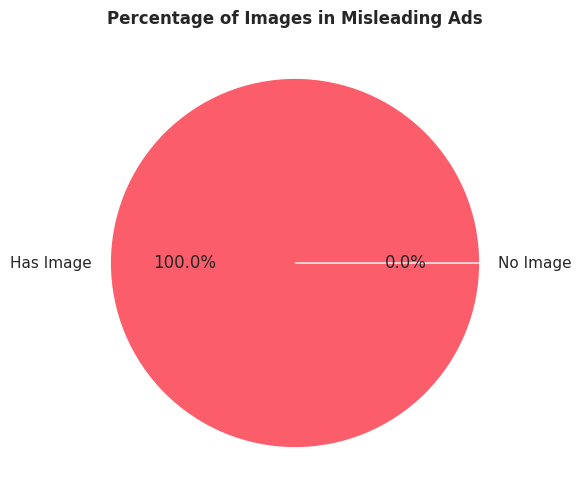

In [16]:
plt.figure(figsize=(6,6))

# ensure both True and False exist
image_counts = misleading_ads['has_image'].value_counts()

image_counts = image_counts.reindex([True, False], fill_value=0)

plt.pie(image_counts,
        labels=['Has Image','No Image'],
        autopct='%1.1f%%',
        colors=['#fc5d6b', '#bbd4fc'])

plt.title("Percentage of Images in Misleading Ads", weight='bold')

plt.show()

## Changing numeric values

In [17]:
#PageNameFeature
df['page_name_len'] = df['page_name'].astype(str).apply(len)

#DateFeatures
df['ad_creation_time'] = pd.to_datetime(df['ad_creation_time'])
df['ad_delivery_start_time'] = pd.to_datetime(df['ad_delivery_start_time'])
df['ad_delivery_stop_time'] = pd.to_datetime(df['ad_delivery_stop_time'])

df['creation_day'] = df['ad_creation_time'].dt.day
df['creation_month'] = df['ad_creation_time'].dt.month

df['duration_days'] = (
    df['ad_delivery_stop_time'] - df['ad_delivery_start_time']
).dt.days

#text features
df['body_text_len'] = df['ad_creative_bodies'].astype(str).apply(len)
df['title_text_len'] = df['ad_creative_link_titles'].astype(str).apply(len)

#Currency
df['currency_encoded'] = df['currency'].astype('category').cat.codes

#Inpression & Spend
df['impressions'] = pd.to_numeric(df['impressions'], errors='coerce')
df['spend'] = pd.to_numeric(df['spend'], errors='coerce')

#Others
df['gender_encoded'] = df['target_gender'].astype('category').cat.codes
df['target_ages'] = df['target_ages'].apply(lambda x: len(ast.literal_eval(x)) if isinstance(x,str) else 0)
df['target_locations'] = df['target_locations'].astype(str).apply(len)
df['languages'] = df['languages'].astype(str).apply(len)
df['publisher_platforms'] = df['publisher_platforms'].astype(str).apply(len)
df['has_image'] = df['ad_snapshot_url'].notna().astype(int)

In [18]:
feature_df = df[[
'page_name_len',
'creation_day',
'creation_month',
'duration_days',
'body_text_len',
'title_text_len',
'currency_encoded',
'impressions',
'spend',
'gender_encoded',
'target_ages',
'target_locations',
'languages',
'publisher_platforms',
'has_image',
'missinformation'
]]

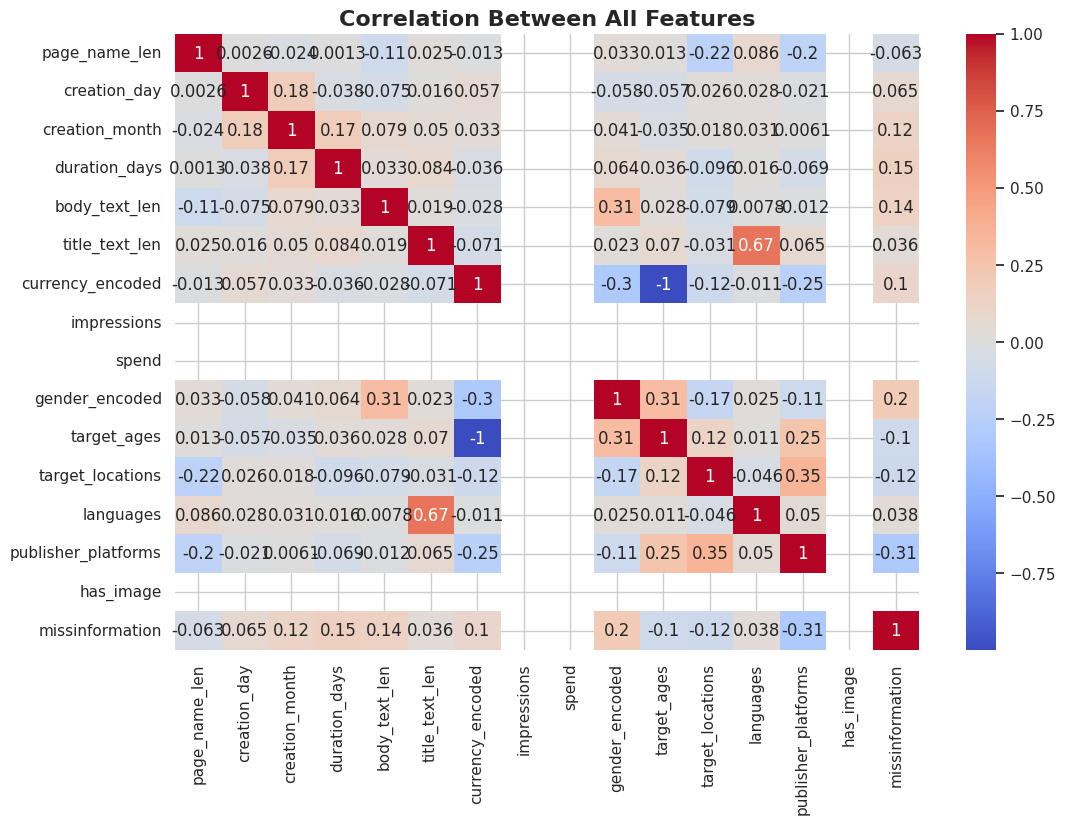

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,8))

sns.heatmap(
    feature_df.corr(),
    annot=True,
    cmap='coolwarm',
    center=0
)

plt.title("Correlation Between All Features", fontsize=16, weight='bold')

plt.show()

In [20]:
corr_target = feature_df.corr()['missinformation'].sort_values(ascending=False)

print(corr_target)

missinformation        1.000000
gender_encoded         0.202734
duration_days          0.150953
body_text_len          0.143794
creation_month         0.123693
currency_encoded       0.101017
creation_day           0.064536
languages              0.038212
title_text_len         0.035868
page_name_len         -0.062867
target_ages           -0.101197
target_locations      -0.121290
publisher_platforms   -0.305430
impressions                 NaN
spend                       NaN
has_image                   NaN
Name: missinformation, dtype: float64


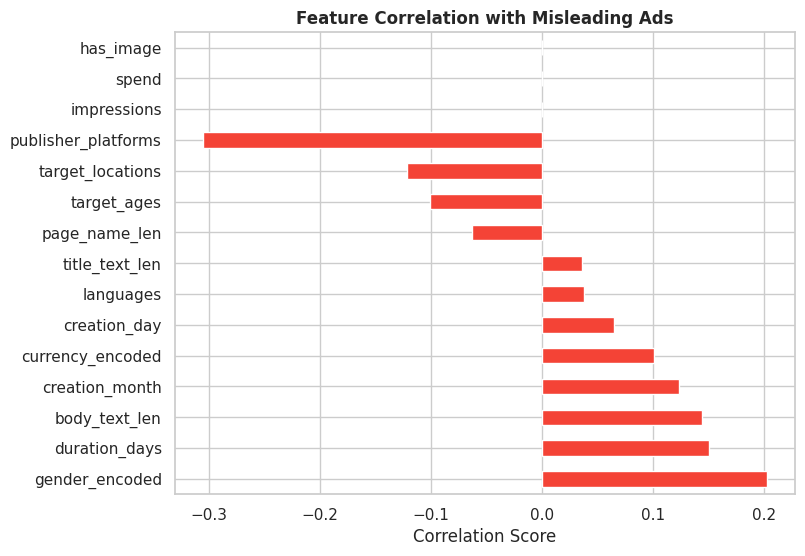

In [21]:
corr_target.drop('missinformation').plot(
    kind='barh',
    figsize=(8,6),
    color='#F44336'
)

plt.title("Feature Correlation with Misleading Ads", weight='bold')
plt.xlabel("Correlation Score")

plt.show()

In [22]:
# convert string list to normal text
df['ad_text'] = df['ad_creative_bodies'].apply(lambda x: ' '.join(ast.literal_eval(x)) if isinstance(x, str) else '')
mis_ads = df[df['missinformation'] == 1]

In [23]:
"""mis_ads['tokens'] = mis_ads['ad_text'].apply(lambda x: word_tokenize(x.lower()))"""

"mis_ads['tokens'] = mis_ads['ad_text'].apply(lambda x: word_tokenize(x.lower()))"

In [24]:
"""from collections import Counter

all_words = []

for words in mis_ads['tokens']:
    all_words.extend(words)

word_counts = Counter(all_words)

top_words = word_counts.most_common(20)

print(top_words)"""

"from collections import Counter\n\nall_words = []\n\nfor words in mis_ads['tokens']:\n    all_words.extend(words)\n\nword_counts = Counter(all_words)\n\ntop_words = word_counts.most_common(20)\n\nprint(top_words)"

In [25]:
df['ad_creation_time'] = pd.to_datetime(df['ad_creation_time'])
df['ad_delivery_start_time'] = pd.to_datetime(df['ad_delivery_start_time'])
df['ad_delivery_stop_time'] = pd.to_datetime(df['ad_delivery_stop_time'])

In [32]:
#ads duration
df['ad_duration_days'] = (
    df['ad_delivery_stop_time'] - df['ad_delivery_start_time']
).dt.days

In [33]:
#launch delay: Low-effort ads often start immediately
df['launch_delay'] = (
    df['ad_delivery_start_time'] - df['ad_creation_time']
).dt.days

In [34]:
#active status: 1 = still running
df['active_status'] = df['ad_delivery_stop_time'].isna().astype(int)

In [35]:
#Burstiness (ads posted per day) - large burst = suspicious
daily_ads = df.groupby('ad_creation_time').size()

df['burstiness'] = df['ad_creation_time'].map(daily_ads)

In [36]:
#ads per page
df['ads_per_page'] = df.groupby('page_id')['id'].transform('count')

In [38]:
#Repeated text ratio
df['text_duplicate'] = df.duplicated('ad_creative_bodies').astype(int)

df['repeated_text_ratio'] = df.groupby('page_id')['text_duplicate'].transform('mean')

In [39]:
#pages with low volume can be scam pages
df['historical_volume'] = df.groupby('page_id')['id'].transform('count')

In [40]:
#Spend per day
df['spend_per_day'] = df['spend'] / df['ad_duration_days']

In [41]:
df['impressions_per_day'] = df['impressions'] / df['ad_duration_days']

In [42]:
df['CPM_estimate'] = (df['spend'] / df['impressions']) * 1000

In [43]:
df['low_spend_high_reach'] = (
    (df['spend'] < df['spend'].median()) &
    (df['impressions'] > df['impressions'].median())
).astype(int)

In [44]:
#age span: large span --> generic scams
df['age_min'] = df['target_ages'].apply(lambda x: int(x[0]) if isinstance(x,list) else None)
df['age_max'] = df['target_ages'].apply(lambda x: int(x[-1]) if isinstance(x,list) else None)

df['age_span'] = df['age_max'] - df['age_min']

In [45]:
df['num_countries'] = df['target_locations'].apply(
    lambda x: len(x) if isinstance(x,list) else 0
)

In [46]:
df['gender_specific'] = (df['target_gender'] != 'All').astype(int)

In [47]:
df['language_count'] = df['languages'].apply(
    lambda x: len(x) if isinstance(x,list) else 0
)

In [48]:
df['platform_count'] = df['publisher_platforms'].apply(
    lambda x: len(x) if isinstance(x,list) else 0
)

In [49]:
df['IG_only_flag'] = df['publisher_platforms'].apply(
    lambda x: 1 if x == ['instagram'] else 0
)

In [50]:
df['FB_only_flag'] = df['publisher_platforms'].apply(
    lambda x: 1 if x == ['facebook'] else 0
)

In [56]:
metadata_features = [
'ad_duration_days',
'launch_delay',
'burstiness',
'active_status',
'ads_per_page',
'repeated_text_ratio',
'page_name_len',
'historical_volume',
'spend_per_day',
'impressions_per_day',
'CPM_estimate',
'low_spend_high_reach',
'age_span',
'num_countries',
'gender_specific',
'language_count',
'platform_count',
'IG_only_flag',
'FB_only_flag'
]

corr = df[metadata_features + ['missinformation']].corr()

corr['missinformation'].sort_values(ascending=False)

,missinformation
missinformation,1.000000
gender_specific,0.274876
ad_duration_days,0.150953
launch_delay,0.092614
active_status,0.062273
page_name_len,-0.062867
ads_per_page,-0.250081
historical_volume,-0.250081
burstiness,-0.255123
repeated_text_ratio,-0.295013


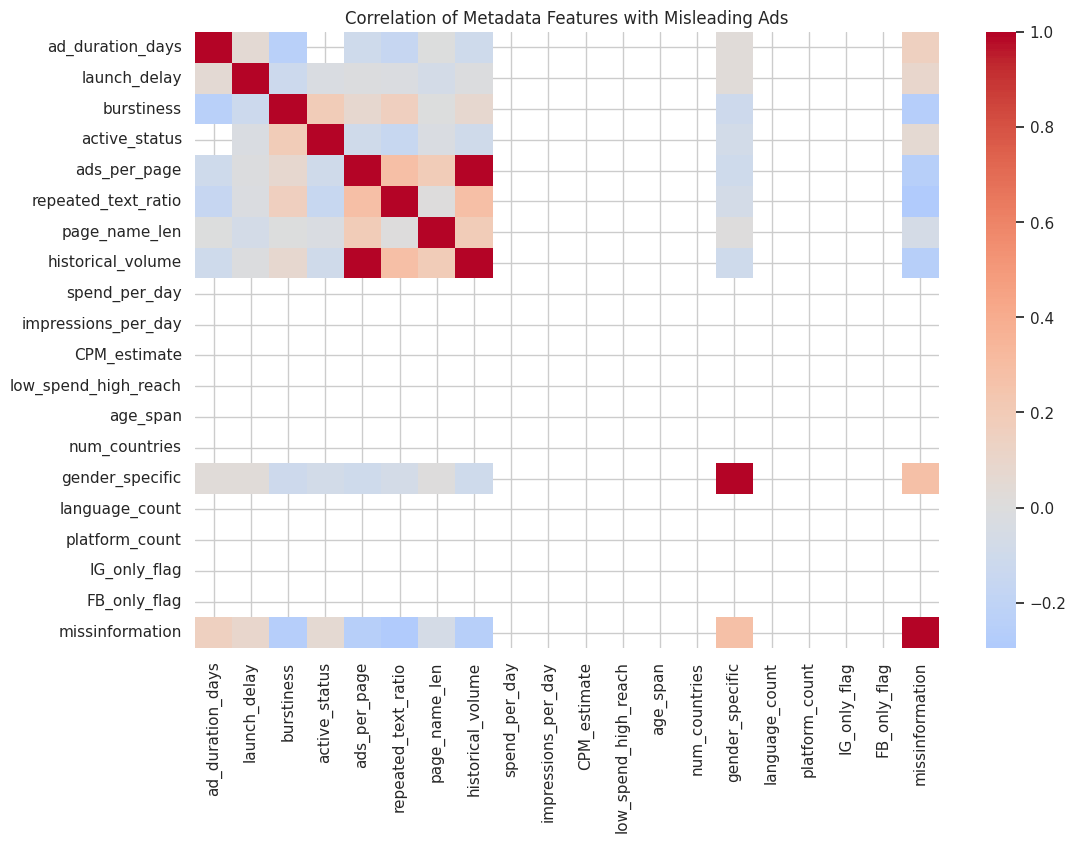

In [57]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,8))

sns.heatmap(
    df[metadata_features + ['missinformation']].corr(),
    cmap='coolwarm',
    center=0
)

plt.title("Correlation of Metadata Features with Misleading Ads")

plt.show()

In [58]:
df.head()

,id,page_id,page_name,ad_creation_time,ad_delivery_start_time,ad_delivery_stop_time,ad_creative_bodies,ad_creative_link_titles,currency,impressions,...,low_spend_high_reach,age_min,age_max,age_span,num_countries,gender_specific,language_count,platform_count,IG_only_flag,FB_only_flag
0,823238210316661,102854402460581,FiberOne Boats,2025-11-10,2025-11-10,2025-11-25,['💓💓Bán lỗ mẫu dép nữ tăng cao 6 cm cho mọi l...,['.'],NaN,NaN,...,0,None,None,NaN,0,1,0,0,0,0
1,871132209123989,136028396253725,DramaBox-movies and drama 8,2026-02-08,2026-02-08,NaT,['Sau năm năm bị kẹt trong hôn nhân không tình...,['(Lồng tiếng)Cuộc đời hoàn hảo không cần anh'],NaN,NaN,...,0,None,None,NaN,0,0,0,0,0,0
2,877151195021133,828292550372769,DramaBox-drama pendek,2026-02-06,2026-02-08,NaT,['Sau năm năm bị kẹt trong hôn nhân không tình...,['(Lồng tiếng)Cuộc đời hoàn hảo không cần anh'],NaN,NaN,...,0,None,None,NaN,0,0,0,0,0,0
3,881581114655479,136028396253725,DramaBox-movies and drama 8,2026-02-08,2026-02-08,NaT,['Sau năm năm bị kẹt trong hôn nhân không tình...,['(Lồng tiếng)Cuộc đời hoàn hảo không cần anh'],NaN,NaN,...,0,None,None,NaN,0,0,0,0,0,0
4,1227833952148512,580340045172078,Dramawave-New short dramas,2026-02-08,2026-02-08,2026-02-08,"['Tái sinh, Nam Mạt trở nên lạnh lùng và quyết...",['Đích Nữ Tàn Nhẫn Đăng Cơ'],NaN,NaN,...,0,None,None,NaN,0,0,0,0,0,0


In [54]:
df.columns

Index(['id', 'page_id', 'page_name', 'ad_creation_time',
       'ad_delivery_start_time', 'ad_delivery_stop_time', 'ad_creative_bodies',
       'ad_creative_link_titles', 'currency', 'impressions', 'spend',
       'target_gender', 'target_ages', 'target_locations', 'languages',
       'publisher_platforms', 'ad_snapshot_url', 'missinformation', 'duration',
       'has_image', 'page_name_len', 'creation_day', 'creation_month',
       'duration_days', 'body_text_len', 'title_text_len', 'currency_encoded',
       'gender_encoded', 'ad_text', 'ad_duration_days', 'launch_delay',
       'active_status', 'burstiness', 'ads_per_page', 'text_duplicate',
       'repeated_text_ratio', 'avg_ad_duration', 'historical_volume',
       'spend_per_day', 'impressions_per_day', 'CPM_estimate',
       'low_spend_high_reach', 'age_min', 'age_max', 'age_span',
       'num_countries', 'gender_specific', 'language_count', 'platform_count',
       'IG_only_flag', 'FB_only_flag'],
      dtype='object')

In [62]:
# create new readable IDs
df['ad_id'] = 'AD_' + (pd.factorize(df['id'])[0] + 1).astype(str)
df['page_id_clean'] = 'PAGE_' + (pd.factorize(df['page_id'])[0] + 1).astype(str)

# remove original columns
df = df.drop(columns=['id', 'page_id'])

In [63]:
df.head()

,page_name,ad_creation_time,ad_delivery_start_time,ad_delivery_stop_time,ad_creative_bodies,ad_creative_link_titles,currency,impressions,spend,target_gender,...,age_max,age_span,num_countries,gender_specific,language_count,platform_count,IG_only_flag,FB_only_flag,ad_id,page_id_clean
0,FiberOne Boats,2025-11-10,2025-11-10,2025-11-25,['💓💓Bán lỗ mẫu dép nữ tăng cao 6 cm cho mọi l...,['.'],NaN,NaN,NaN,Women,...,None,NaN,0,1,0,0,0,0,AD_1,PAGE_1
1,DramaBox-movies and drama 8,2026-02-08,2026-02-08,NaT,['Sau năm năm bị kẹt trong hôn nhân không tình...,['(Lồng tiếng)Cuộc đời hoàn hảo không cần anh'],NaN,NaN,NaN,All,...,None,NaN,0,0,0,0,0,0,AD_2,PAGE_2
2,DramaBox-drama pendek,2026-02-06,2026-02-08,NaT,['Sau năm năm bị kẹt trong hôn nhân không tình...,['(Lồng tiếng)Cuộc đời hoàn hảo không cần anh'],NaN,NaN,NaN,All,...,None,NaN,0,0,0,0,0,0,AD_3,PAGE_3
3,DramaBox-movies and drama 8,2026-02-08,2026-02-08,NaT,['Sau năm năm bị kẹt trong hôn nhân không tình...,['(Lồng tiếng)Cuộc đời hoàn hảo không cần anh'],NaN,NaN,NaN,All,...,None,NaN,0,0,0,0,0,0,AD_4,PAGE_2
4,Dramawave-New short dramas,2026-02-08,2026-02-08,2026-02-08,"['Tái sinh, Nam Mạt trở nên lạnh lùng và quyết...",['Đích Nữ Tàn Nhẫn Đăng Cơ'],NaN,NaN,NaN,All,...,None,NaN,0,0,0,0,0,0,AD_5,PAGE_4


In [64]:
df.to_csv("misleading_ads_dataset.csv", index=False)

In [66]:
features = ['ad_id'] + metadata_features + ['missinformation']

df[features].to_csv("metadata_features_dataset.csv", index=False)